https://www.youtube.com/watch?v=4QHg8Ix8WWQ

In [11]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv("./data.csv")

In [6]:
df.head()

,doi,text_id,text,sdg,labels_negative,labels_positive,agreement
0,10.6027/9789289342698-7-en,00021941702cd84171ff33962197ca1f,"From a gender perspective, Paulgaard points ou...",5,1,8,0.777778
1,10.18356/eca72908-en,00028349a7f9b2485ff344ae44ccfd6b,Labour legislation regulates maximum working h...,11,2,1,0.333333
2,10.1787/9789264289062-4-en,0004eb64f96e1620cd852603d9cbe4d4,The average figure also masks large difference...,3,1,8,0.777778
3,10.1787/3726edff-en,0005d3e8b213d9e2cb967666e1aca2e9,Applied research is directed ‚Äúprimarily towa...,9,3,6,0.333333
4,10.1787/5k9b7bn5qzvd-en,0006a887475ccfa5a7f5f51d4ac83d02,The extent to which they are akin to corruptio...,3,1,2,0.333333


In [12]:
def plot_sdg_distribution(df, agreement_col='agreement', sdg_col='sdg', bins=5, palette='viridis'):
    """
    Plots the distribution of SDGs across different agreement levels.

    Parameters:
    - df (pd.DataFrame): The DataFrame containing the data.
    - agreement_col (str): The name of the agreement column.
    - sdg_col (str): The name of the SDG categorical column.
    - bins (int or list): Number of bins or specific bin edges for agreement scores.
    - palette (str or list): Seaborn palette for the plot.

    Returns:
    - None: Displays the plot.
    """
    # Check if the specified columns exist in the DataFrame
    if agreement_col not in df.columns:
        raise ValueError(f"'{agreement_col}' column not found in the DataFrame.")
    if sdg_col not in df.columns:
        raise ValueError(f"'{sdg_col}' column not found in the DataFrame.")

    # Bin the agreement scores
    df['agreement_bin'] = pd.cut(df[agreement_col], bins=bins, labels=False, include_lowest=True)

    # Optionally, create labels for the bins
    if isinstance(bins, int):
        bin_edges = pd.cut(df[agreement_col], bins=bins, retbins=True)[1]
        bin_labels = [f"{round(bin_edges[i], 2)} - {round(bin_edges[i+1], 2)}" for i in range(len(bin_edges)-1)]
        df['agreement_bin'] = pd.cut(df[agreement_col], bins=bins, labels=bin_labels, include_lowest=True)
    else:
        # If bins are provided as edges, create labels accordingly
        bin_labels = [f"{round(bins[i], 2)} - {round(bins[i+1], 2)}" for i in range(len(bins)-1)]
        df['agreement_bin'] = pd.cut(df[agreement_col], bins=bins, labels=bin_labels, include_lowest=True)

    # Set the plot style
    sns.set(style="whitegrid")

    # Initialize the matplotlib figure
    plt.figure(figsize=(14, 8))

    # Create a count plot
    ax = sns.countplot(
        data=df,
        x=sdg_col,
        hue='agreement_bin',
        palette=palette,
        dodge=True
    )

    # Add titles and labels
    plt.title('Distribution of SDGs Across Agreement Levels', fontsize=16)
    plt.xlabel('SDG', fontsize=14)
    plt.ylabel('Count', fontsize=14)

    # Adjust legend
    plt.legend(title='Agreement Level', title_fontsize='13', fontsize='11', bbox_to_anchor=(1.05, 1), loc='upper left')

    # Improve layout
    plt.tight_layout()

    # Show plot
    plt.show()

    # Optionally, remove the temporary 'agreement_bin' column
    df.drop('agreement_bin', axis=1, inplace=True)

In [9]:
custom_bins = [0, 0.2, 0.4, 0.6, 0.8, 1.0]

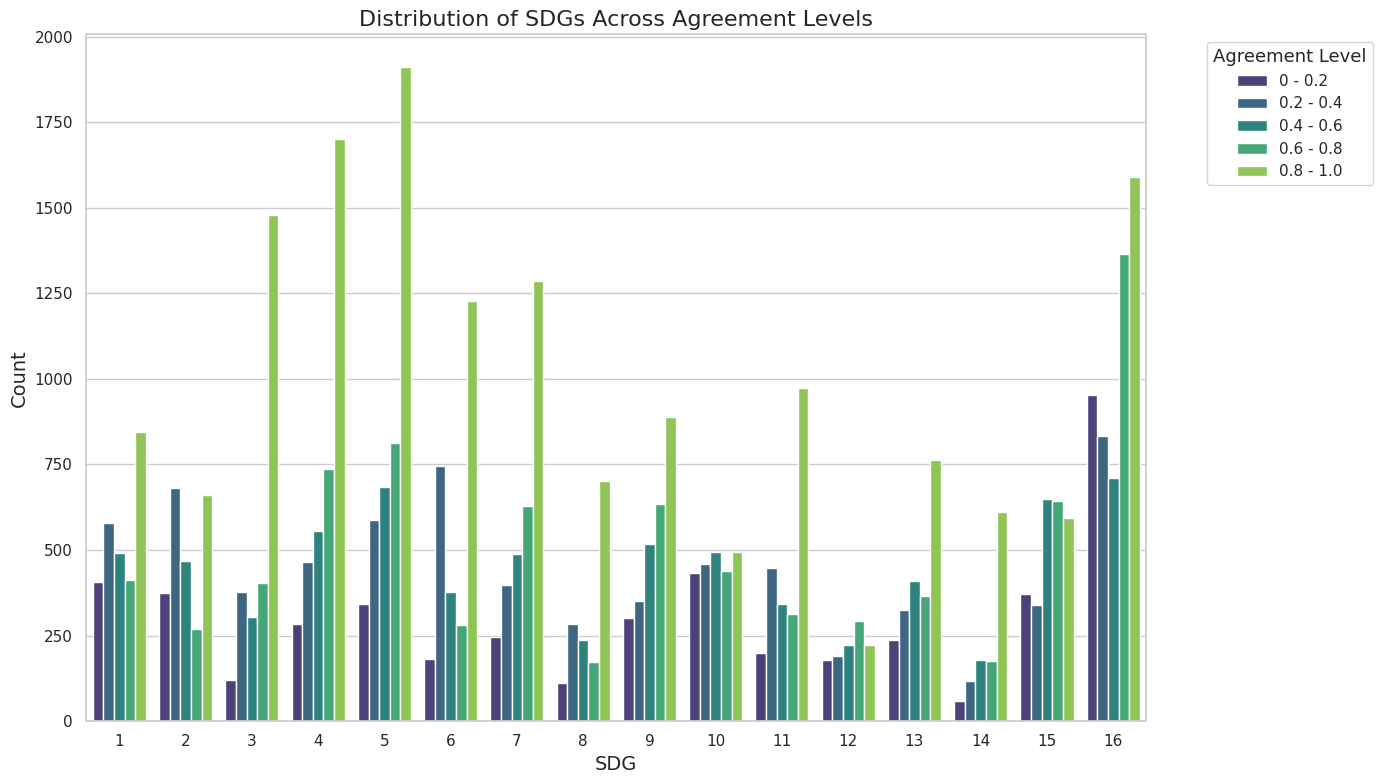

In [13]:
plot_sdg_distribution(df, 'agreement', 'sdg', custom_bins)

In [19]:
def plot_sdg_distribution_filtered(
    df,
    agreement_col='agreement',
    sdg_col='sdg',
    bins=None,  # Make bins optional by defaulting to None
    palette='viridis',
    min_agreement=None
):
    """
    Plots the distribution of SDGs across different agreement levels, with an optional minimum agreement threshold and optional binning.

    Parameters:
    - df (pd.DataFrame): The DataFrame containing the data.
    - agreement_col (str): The name of the agreement column.
    - sdg_col (str): The name of the SDG categorical column.
    - bins (int or list, optional): Number of bins or specific bin edges for agreement scores. If None, no binning is applied.
    - palette (str or list): Seaborn palette for the plot.
    - min_agreement (float, optional): Minimum agreement score to include in the plot. Defaults to None.

    Returns:
    - None: Displays the plot.
    """
    # Validate columns
    if agreement_col not in df.columns:
        raise ValueError(f"'{agreement_col}' column not found in the DataFrame.")
    if sdg_col not in df.columns:
        raise ValueError(f"'{sdg_col}' column not found in the DataFrame.")

    # Apply minimum agreement filter if specified
    if min_agreement is not None:
        if not (0 <= min_agreement <= 1):
            raise ValueError("min_agreement must be between 0 and 1.")
        filtered_df = df[df[agreement_col] >= min_agreement].copy()
        if filtered_df.empty:
            raise ValueError(f"No data points with '{agreement_col}' >= {min_agreement}.")
        print(f"Filtered data to include only rows with '{agreement_col}' >= {min_agreement}.")
    else:
        filtered_df = df.copy()

    # Apply binning if specified
    if bins is not None:
        if isinstance(bins, int):
            # Create equal-width bins
            bin_edges = pd.cut(filtered_df[agreement_col], bins=bins, retbins=True, include_lowest=True)[1]
            bin_labels = [f"{round(bin_edges[i], 2)} - {round(bin_edges[i+1], 2)}" for i in range(len(bin_edges)-1)]
            filtered_df['agreement_bin'] = pd.cut(filtered_df[agreement_col], bins=bins, labels=bin_labels, include_lowest=True)
        else:
            # Assume bins are provided as edges
            bin_labels = [f"{round(bins[i], 2)} - {round(bins[i+1], 2)}" for i in range(len(bins)-1)]
            filtered_df['agreement_bin'] = pd.cut(filtered_df[agreement_col], bins=bins, labels=bin_labels, include_lowest=True)
        hue_variable = 'agreement_bin'
    else:
        hue_variable = None  # No hue if no binning

    # Set the plot style
    sns.set(style="whitegrid")

    # Initialize the matplotlib figure
    plt.figure(figsize=(14, 8))

    # Create the count plot
    if hue_variable:
        ax = sns.countplot(
            data=filtered_df,
            x=sdg_col,
            hue=hue_variable,
            palette=palette,
            dodge=True
        )
    else:
        ax = sns.countplot(
            data=filtered_df,
            x=sdg_col,
            palette=palette
        )

    # Add titles and labels
    plt.title('Distribution of SDGs' + (f' (Agreement >= {min_agreement})' if min_agreement else ''), fontsize=16)
    plt.xlabel('SDG', fontsize=14)
    plt.ylabel('Count', fontsize=14)

    # Adjust legend if binning is applied
    if hue_variable:
        plt.legend(title='Agreement Level', title_fontsize='13', fontsize='11', bbox_to_anchor=(1.05, 1), loc='upper left')

    # Improve layout
    plt.tight_layout()

    # Show plot
    plt.show()

    # Clean up temporary column if binning was applied
    if bins is not None:
        filtered_df.drop('agreement_bin', axis=1, inplace=True)



Filtered data to include only rows with 'agreement' >= 0.8.


<ipython-input-19-fa8a4bfb44f0>:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


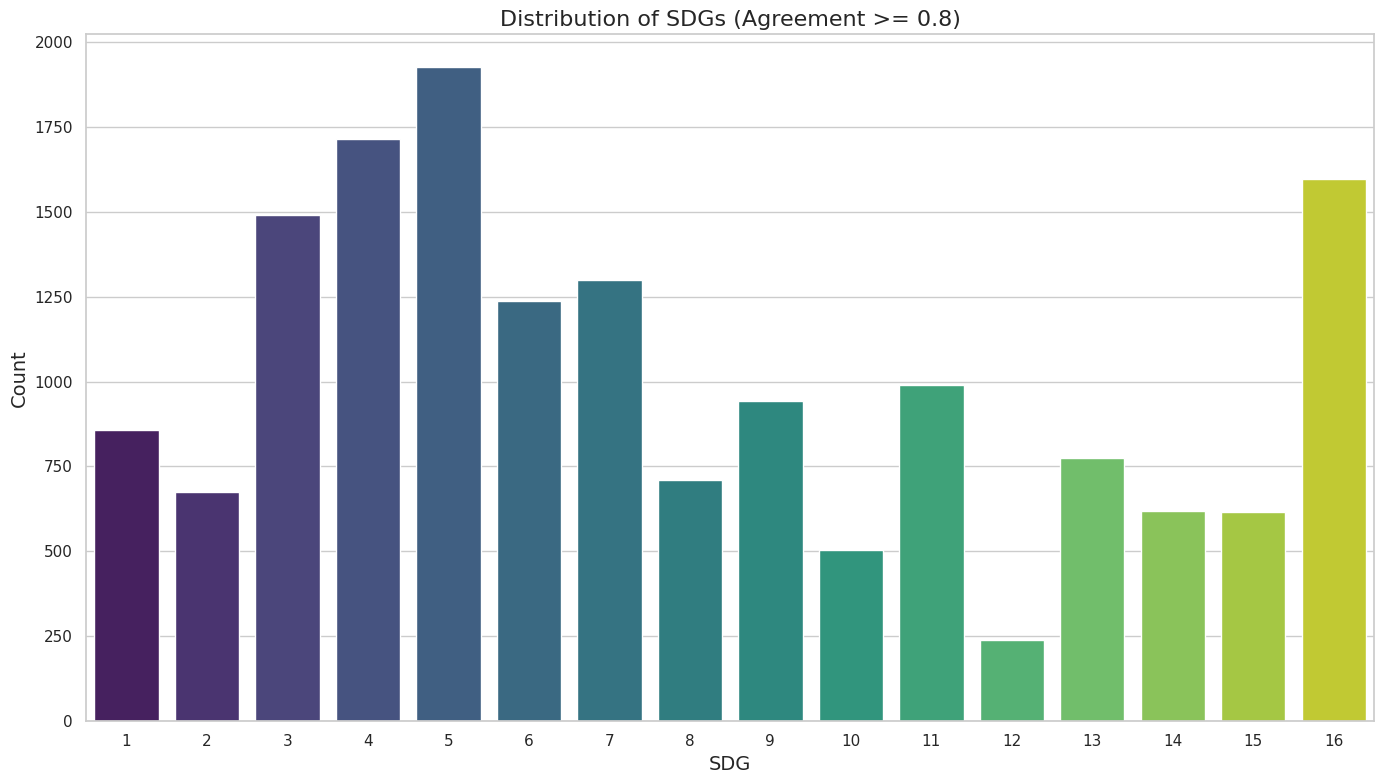

In [20]:
plot_sdg_distribution_filtered(
    df,
    agreement_col='agreement',
    sdg_col='sdg',
    min_agreement=0.8  # Set the minimum agreement threshold
)
